In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def filter_high_r2(df, r2_col_index=40, drempel=0.9):
    """
    Filtert de DataFrame zodat alleen rijen overblijven waarbij de R^2 waarde 
    in de Z-richting (index 40 / 41e kolom) groter is dan de ingestelde drempelwaarde (0.9).
    """
    # Zet de kolom om naar numeriek (verandert evt. foutieve tekst in NaN)
    df[r2_col_index] = pd.to_numeric(df[r2_col_index], errors='coerce')
    
    # Filter de dataframe en stuur de aangepaste versie terug
    df_filtered = df[df[r2_col_index] > drempel].copy()
    return df_filtered


def read_box_compression_data(cif_name, base_dir=r".\data", csv_path="combined_perovskite_data.csv"):
    """
    Leest de LAMMPS compressie data in voor een specifieke CIF.
    Controleert in de combined_perovskite_data.csv wat de daadwerkelijke Z-as is (kolom 17 / index 16).
    Wisselt lx of ly om met lz als dat nodig is.
    """
    folder_path = os.path.join(base_dir, str(cif_name))
    file_name = f"{cif_name}_box_compression_continuous.txt"
    file_path = os.path.join(folder_path, file_name)
    
    if not os.path.exists(file_path):
        print(f"Fout: Kan bestand niet vinden op pad: {file_path}")
        return None, None
        
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#'): 
                continue
            parts = line.strip().split()
            if len(parts) >= 4:
                data.append([float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])

    if not data:
        print(f"Waarschuwing: Geen bruikbare data gevonden in {file_path}")
        return None, None

    # Maak de DataFrame aan
    df = pd.DataFrame(data, columns=['TimeStep', 'lx', 'ly', 'lz'])

    # --- Z-AS OMWISSELEN O.B.V. CSV ---
    if os.path.exists(csv_path):
        try:
            # header=None zorgt ervoor dat we de eerste rij als data behandelen
            df_csv = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
            col_cif = 0  # Eerste kolom (A)
            col_z_axis = 16  # 17e kolom (Q)
            
            # Controleer of kolom 16 wel bestaat
            if len(df_csv.columns) >= 17:
                # Zoek de rij op basis van de CIF naam
                rij_index = df_csv.index[df_csv[col_cif].astype(str) == str(cif_name)].tolist()
                
                if rij_index:
                    idx = rij_index[0]
                    z_richting = str(df_csv.at[idx, col_z_axis]).strip().lower()
                    
                    if z_richting == 'a':
                        df[['lx', 'lz']] = df[['lz', 'lx']]
                        print(f"ℹ️ As-correctie (CIF {cif_name}): Data van 'lx' verwisseld met 'lz' (Z-richting = A).")
                    elif z_richting == 'b':
                        df[['ly', 'lz']] = df[['lz', 'ly']]
                        print(f"ℹ️ As-correctie (CIF {cif_name}): Data van 'ly' verwisseld met 'lz' (Z-richting = B).")
                    elif z_richting == 'c':
                        print(f"ℹ️ As-correctie (CIF {cif_name}): Geen wissel nodig, lz is correct (Z-richting = C).")
                    else:
                        print(f"Waarschuwing: Z-richting in kolom Q is onbekend ('{z_richting}'). Geen assen verwisseld.")
                else:
                    print(f"Waarschuwing: CIF {cif_name} niet gevonden in {csv_path} om de Z-as te controleren.")
        except Exception as e:
            print(f"Fout bij het controleren van de Z-as in {csv_path}: {e}")
            
    return df, folder_path


def plot_box_compression(df, cif_name, save_dir="."):
    """Maakt een grafiek met drie subplots (lx, ly, lz) op basis van een DataFrame."""
    if df is None or df.empty:
        return
        
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axs[0].plot(df['TimeStep'], df['lx'], color='blue', label='lx')
    axs[0].set_ylabel('lx (Å)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(df['TimeStep'], df['ly'], color='orange', label='ly')
    axs[1].set_ylabel('ly (Å)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(df['TimeStep'], df['lz'], color='green', label='lz')
    axs[2].set_ylabel('lz (Å)')
    axs[2].set_xlabel('TimeStep')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    plt.tight_layout()
    output_img = os.path.join(save_dir, f"{cif_name}_box_compression_plot.png")
    plt.savefig(output_img)
    plt.close() # Voorkomt dat er honderden plots in je output blijven hangen bij een for-loop

def verwerk_compressie_data(df_box, cif_name, csv_path="combined_perovskite_data.csv"):
    """Berekent gemiddelden, hellingen en de R2-waarde, en voegt dit toe aan de CSV."""
    intervallen = {
        1: (30000, 80000),
        1000: (110000, 160000),
        2000: (190000, 240000),
        3000: (270000, 320000),
        4000: (350000, 400000)
    }
    
    assen = ['lx', 'ly', 'lz']
    drukken = list(intervallen.keys())
    
    gemiddelden = {as_naam: [] for as_naam in assen}
    te_schrijven_waarden = [] 
    
    # 1. BEREKEN DE GEMIDDELDEN (Lx, Ly, Lz, V per druk)
    for druk, (start, eind) in intervallen.items():
        df_gefilterd = df_box[(df_box['TimeStep'] >= start) & (df_box['TimeStep'] <= eind)]
        for as_naam in assen:
            gem = df_gefilterd[as_naam].mean() if not df_gefilterd.empty else np.nan
            gemiddelden[as_naam].append(gem)
            te_schrijven_waarden.append(gem)
            
    # 2. BEREKEN DE HELLINGEN (dV/dp), COMPRESSIBILITEIT (b = -1/V * dV/dp) EN DE R2 WAARDE
    hellingen = {}
    compressibiliteiten = {}
    mse = {}
    r2_waarden = {} 
    
    for as_naam in assen:
        geldige_drukken = [p for p, val in zip(drukken, gemiddelden[as_naam]) if not np.isnan(val)]
        geldige_gemiddelden = [val for val in gemiddelden[as_naam] if not np.isnan(val)]
        
        # We hebben minimaal 2 punten nodig om een lijn te trekken
        if len(geldige_drukken) > 1:
            p_fit = np.polyfit(geldige_drukken, geldige_gemiddelden, 1)
            helling = p_fit[0]   # Dit is dV/dp (of dL/dp voor de assen)
            snijpunt = p_fit[1]
            
            # BEREKEN DE COMPRESSIBILITEIT (beta)
            # We gebruiken het startvolume (V0) of de startlengte (L0) bij de laagste gemeten druk
            X0 = geldige_gemiddelden[0]
            beta = -(1 / X0) * helling
            
            # BEREKEN R-SQUARED (R2)
            voorspelde_waardes = [helling * x + snijpunt for x in geldige_drukken]
            
            # RSS: Residual Sum of Squares (afwijking van model)
            rss = np.sum([(echt - voorspeld)**2 for echt, voorspeld in zip(geldige_gemiddelden, voorspelde_waardes)])
            
            # TSS: Total Sum of Squares (afwijking van gemiddelde)
            gemiddelde_echt = np.mean(geldige_gemiddelden)
            tss = np.sum([(echt - gemiddelde_echt)**2 for echt in geldige_gemiddelden])
            
            # R2 formule (voorkom delen door nul als TSS 0 is)
            r2 = (1 - (rss / tss)) if tss != 0 else 1.0
            
            hellingen[as_naam] = helling
            compressibiliteiten[as_naam] = beta
            mse[as_naam] = rss
            r2_waarden[as_naam] = r2
        else:
            hellingen[as_naam] = np.nan
            compressibiliteiten[as_naam] = np.nan
            mse[as_naam] = np.nan
            r2_waarden[as_naam] = np.nan
            
        # Schrijf de compressibiliteit weg in plaats van puur de helling
        te_schrijven_waarden.append(compressibiliteiten[as_naam])
        
    for as_naam in assen:
        te_schrijven_waarden.append(mse[as_naam])
            
    for as_naam in assen:
        te_schrijven_waarden.append(r2_waarden[as_naam])

    # 3. WEGSCHRIJVEN NAAR DE CSV
    if os.path.exists(csv_path):
        try:
            df_csv = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
            col_cif = 0
            
            rij_index = df_csv.index[df_csv[col_cif].astype(str) == str(cif_name)].tolist()
            
            if rij_index:
                idx = rij_index[0]
                start_col = 17 
                for i, waarde in enumerate(te_schrijven_waarden):
                    col_id = start_col + i
                    if col_id not in df_csv.columns:
                        df_csv[col_id] = np.nan
                    df_csv.at[idx, col_id] = waarde
                
                df_csv.to_csv(csv_path, sep=';', index=False, header=False)
                print(f"✓ Data, compressibiliteit én R² voor '{cif_name}' succesvol toegevoegd.")
            else:
                print(f"Waarschuwing: CIF '{cif_name}' niet gevonden bij het wegschrijven.")
        except Exception as e:
            print(f"Fout bij het wegschrijven: {e}")
            
    # Retourneer nu de compressibiliteiten in plaats van de losse hellingen
    return gemiddelden, compressibiliteiten, r2_waarden, drukken


def plot_compressie_trend(gemiddelden, hellingen, r2_waarden, drukken, cif_name, save_dir="."):
    """Plot de gemiddelde boxlengtes tegen de druk, inclusief trendlijn en R² in de legenda."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    kleuren = ['blue', 'orange', 'green']
    assen = ['lx', 'ly', 'lz']

    for i, as_naam in enumerate(assen):
        y_waardes = gemiddelden[as_naam]
        axs[i].plot(drukken, y_waardes, marker='o', linestyle='', color=kleuren[i], label='Measurements')
        
        geldige_drukken = [p for p, val in zip(drukken, y_waardes) if not np.isnan(val)]
        geldige_gemiddelden = [val for val in y_waardes if not np.isnan(val)]
        
        if len(geldige_drukken) > 1:
            
            helling_val, snijpunt = np.polyfit(geldige_drukken, geldige_gemiddelden, 1)
            r2_val = r2_waarden[as_naam]
            
            trendlijn = [helling_val * p + snijpunt for p in drukken]
            
            # --- NIEUWE LEGENDA OPMAAK VOOR R2 ---
            # De R2 krijgt 3 decimalen achter de komma (bijv. 0.985)
            if not np.isnan(r2_val):
                label_tekst = f'Trend (a={helling_val:.2e}, R²={r2_val:.3f})'
            else:
                label_tekst = f'Trend (a={helling_val:.2e})'
                
            axs[i].plot(drukken, trendlijn, color='red', linestyle='--', label=label_tekst)
        
        axs[i].set_title(f"{as_naam.upper()}-axis")
        axs[i].set_xlabel("Pressure (atm)")
        axs[i].set_ylabel(f"{as_naam} (Å)")
        axs[i].set_xticks(drukken)
        axs[i].grid(True, linestyle=':', alpha=0.7)
        axs[i].legend()

    plt.tight_layout()
    output_img = os.path.join(save_dir, f"{cif_name}_compressie_trend.png")
    plt.savefig(output_img)
    plt.close() #close or show voor spam
    
def plot_35_en_41(csv_path, separator=';', output_dir="./plots"):
    """
    Leest een dataset in en maakt een scatter plot van de 41ste kolom (X-as) 
    tegen de 35ste kolom (Y-as). Bepaalt ook min/max van de X-as.
    """
    
    try:
        # Lees de dataset in
        df = pd.read_csv(csv_path, sep=separator)
        
        # Selecteer de data
        data_y = df.iloc[:, 34]
        data_x = df.iloc[:, 40]
        
        # --- NIEUW: Min en Max bepalen ---
        min_x = data_x.min()
        max_x = data_x.max()
        
        # idxmin() en idxmax() geven de rij-index van de min/max waarden
        idx_min = data_x.idxmin()
        idx_max = data_x.idxmax()
        
        # Optioneel: Als je de daadwerkelijke naam/ID uit de eerste kolom wilt weten
        naam_min = df.iloc[idx_min, 0]
        naam_max = df.iloc[idx_max, 0]
        
        print("-" * 30)
        print(f"Minimum X-waarde (R^2): {min_x}, ID/Naam: {naam_min})")
        print(f"Maximum X-waarde (R^2): {max_x}, ID/Naam: {naam_max})")
        print("-" * 30)
        # ---------------------------------

        lowR = []
        highR = []
        
        for i, a in enumerate(data_x):
            if a < 0.9:
                lowR.append([i,a])
            elif a >= 0.9: # Tip: maak hier >= van, anders vallen waarden van exact 0.9 weg
                highR.append([i,a])
                
        print(f"low R^2: {len(lowR)}")
        print(f"high R^2: {len(highR)}")
        # print(lowR) # Uitgecommentarieerd om de output schoon te houden, zet gerust aan
        
        # Maak de scatter plot
        plt.figure(figsize=(10, 6))
        plt.scatter(data_x, data_y, alpha=0.6, edgecolors='w', linewidth=0.5, color='royalblue')
        
        # Labels en titel toevoegen
        plt.axis(xmin=0, xmax=1) # Iets meer ruimte rechts voor de max waarden
        plt.ylabel('Z-compressibility (1/atm)')
        plt.xlabel('R² of lz-p fit')
        
        # Verticale lijn voor de drempelwaarde
        plt.axvline(x=0.9, color='red', linestyle=':')
        
        # Tekst toevoegen
        plt.text(0.8, data_y.min(), f"R² = 0.9", color='red', ha='center', size=16)
        
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Zorg dat de output map bestaat
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        save_path = os.path.join(output_dir, "R^2_scatter.png")
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ R^2 scatterplot opgeslagen in: {save_path}")
        plt.show()
        
    except FileNotFoundError:
        print(f"Fout: Het bestand '{csv_path}' is niet gevonden.")
    except Exception as e:
        print(f"Er is een onverwachte fout opgetreden: {e}")
        
def plot_compressibility_per_type_matplotlib(csv_path="combined_perovskite_data.csv", output_dir="./plots"):
    """
    Maakt een boxplot met Matplotlib van de compressibiliteit (kolom 35 / AI) per type (kolom 6 / F).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # Lees CSV in zonder header (zoals afgesproken)
    df = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
    
    # --- NIEUW: Filter R^2 > 0.9 ---
    df = filter_high_r2(df)
    
    # Selecteer kolommen en filter 'Type' naar tekst
    df_plot = df[[5, 34]].copy()
    df_plot.columns = ['Type', 'Compressibility']
    df_plot['Type'] = df_plot['Type'].astype(str).str.strip()
    
    # Groepeer de data voor de boxplot
    gewenste_types = ['RP', 'DJ', 'else']
    data_to_plot = []
    labels = []
    
    for t in gewenste_types:
        # Haal de compressibiliteitswaarden op voor dit type, filter NaN eruit
        waarden = df_plot[df_plot['Type'] == t]['Compressibility'].dropna()
        print(f"for {t}: {len(waarden)} datapoints")
        data_to_plot.append(waarden)
        labels.append(t)
    
    # Maak de plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    bplot = ax.boxplot(data_to_plot, label=labels, patch_artist=True, medianprops={'color': 'black'})
    
    # Kleuren toewijzen aan de boxen
    kleuren = ['#66b3ff', '#ffcc99', '#99ff99']
    for patch, color in zip(bplot['boxes'], kleuren):
        patch.set_facecolor(color)
    
    ax.set_xlabel('Material type')
    ax.set_ylabel('Compressibility (Å/atm)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Opslaan
    save_path = os.path.join(output_dir, "compressibility_boxplot_mpl.png")
    plt.savefig(save_path)
    print(f"✓ Boxplot opgeslagen in: {save_path}")
    plt.show()


def plot_compressibility_per_n(csv_path="combined_perovskite_data.csv", output_dir="./plots"):
    """
    Maakt een boxplot van de compressibiliteit (kolom 35) per n-waarde (kolom 3).
    Filtert de data zodat uitsluitend n=1 t/m n=7 op de x-as terechtkomt.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # Lees CSV in zonder header
    df = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
    
    # --- NIEUW: Filter R^2 > 0.9 ---
    df = filter_high_r2(df)
    
    # Selecteer de relevante kolommen
    df_plot = df[[2, 34]].copy()
    df_plot.columns = ['n_waarde', 'Compressibility']
    
    # Zorg dat de n-waarden en compressibiliteit schoon zijn
    df_plot['n_waarde'] = df_plot['n_waarde'].astype(str).str.strip()
    
    # Forceer de compressibiliteit naar een numeriek type. 
    df_plot['Compressibility'] = pd.to_numeric(df_plot['Compressibility'], errors='coerce')
    
    # Filter: Alleen n=1 t/m n=7
    toegestane_n = ['1', '2', '3', '4', '5', '6', '7']
    data_to_plot = []
    labels = []
    
    for n in toegestane_n:
        waarden = df_plot[df_plot['n_waarde'] == n]['Compressibility'].dropna()
        
        if True == True: # Dezelfde conditie als in de originele code
            data_to_plot.append(waarden)
            labels.append(f"n={n}")
            print(f"n={n}: {len(waarden)}")
            
    if not data_to_plot:
        print("Geen data gevonden voor n=1 t/m n=7.")
        return
    
    # Maak de plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bplot = ax.boxplot(data_to_plot, label=labels, patch_artist=True, medianprops={'color': 'black'})
    
    for patch in bplot['boxes']:
        patch.set_facecolor('#ff9999') # Zacht roze/rood
    
    ax.set_xlabel('n')
    ax.set_ylabel('Compressability in Z-direction (Å/atm)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Opslaan
    save_path = os.path.join(output_dir, "compressibility_n1_to_n7_boxplot.png")
    plt.savefig(save_path)
    print(f"✓ Boxplot (n=1 t/m 7) opgeslagen in: {save_path}")
    plt.show()


def plot_scatter_xy_vs_z_compressibility(csv_path="combined_perovskite_data.csv", output_dir="./plots"):
    """
    Maakt een scatterplot met de gemiddelde X/Y compressibiliteit op de x-as 
    en de Z compressibiliteit op de y-as. 
    De punten krijgen een kleur op basis van het materiaaltype (RP, DJ, else).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # Lees CSV in zonder header
    df = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
    
    # --- NIEUW: Filter R^2 > 0.9 ---
    df = filter_high_r2(df)
    
    # Haal de juiste kolommen op: Type (5), X-comp (32), Y-comp (33), Z-comp (34)
    df_plot = df[[5, 32, 33, 34]].copy()
    df_plot.columns = ['Type', 'X_comp', 'Y_comp', 'Z_comp']
    
    # Zorg dat 'Type' schone tekst is
    df_plot['Type'] = df_plot['Type'].astype(str).str.strip()
    
    # Zet de compressibiliteiten om naar getallen (zet tekst/streepjes om naar NaN)
    for col in ['X_comp', 'Y_comp', 'Z_comp']:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
        
    # Verwijder rijen waar één van de drie compressibiliteiten ontbreekt (NaN)
    df_plot = df_plot.dropna(subset=['X_comp', 'Y_comp', 'Z_comp'])
    
    # BEREKEN DE GEMIDDELDE X/Y COMPRESSIBILITEIT
    df_plot['XY_avg_comp'] = (df_plot['X_comp'] + df_plot['Y_comp']) / 2
    
    # Plot instellingen
    fig, ax = plt.subplots(figsize=(9, 7))
    
    groepen = {
        'else': {'kleur': '#2ca02c', 'label': 'Overig (else)'},     # Groen
        'RP': {'kleur': '#1f77b4', 'label': 'Ruddlesden-Popper (RP)'}, # Blauw
        'DJ': {'kleur': '#ff7f0e', 'label': 'Dion-Jacobson (DJ)'},    # Oranje
    }
    
    for type_naam, opmaak in groepen.items():
        df_groep = df_plot[df_plot['Type'] == type_naam]
        ax.scatter(
            df_groep['XY_avg_comp'], 
            df_groep['Z_comp'], 
            c=opmaak['kleur'], 
            label=opmaak['label'], 
            alpha=0.7,      
            edgecolors='k', 
            s=60            
        )
        
    ax.set_xlabel('Average X/Y Compressibility (atm^-1)', fontsize=12)
    ax.set_ylabel('Z Compressibility (atm^-1)', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()
    
    # Opslaan
    save_path = os.path.join(output_dir, "scatter_xy_vs_z_compressibility.png")
    plt.savefig(save_path)
    print(f"✓ Scatterplot (XY vs Z) opgeslagen in: {save_path}")
    plt.show()


def plot_bandgaps_vs_z_compressibility(csv_path="combined_perovskite_data.csv", output_dir="./plots"):
    """
    Maakt twee scatterplots naast elkaar: 
    Links de berekende bandgap (kolom 9/I), rechts de experimentele bandgap (kolom 10/J) 
    tegen de Z compressibiliteit (kolom 35/AI).
    Lege cellen worden veilig genegeerd zonder andere data te beïnvloeden.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # Lees CSV in zonder header
    df = pd.read_csv(csv_path, sep=';', header=None, low_memory=False)
    
    # --- NIEUW: Filter R^2 > 0.9 ---
    df = filter_high_r2(df)
    
    # Haal de juiste kolommen op: Type (5), Calc Bandgap (8), Exp Bandgap (9), Z-comp (34)
    df_plot = df[[5, 8, 9, 34]].copy()
    df_plot.columns = ['Type', 'Calc_BG', 'Exp_BG', 'Z_comp']
    
    # Zorg dat 'Type' schone tekst is
    df_plot['Type'] = df_plot['Type'].astype(str).str.strip()
    
    # Zet alles om naar getallen.
    for col in ['Calc_BG', 'Exp_BG', 'Z_comp']:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
        
    # SPLITS DE DATA:
    df_calc = df_plot.dropna(subset=['Calc_BG', 'Z_comp'])
    df_exp = df_plot.dropna(subset=['Exp_BG', 'Z_comp'])
    
    # Maak een figuur met 2 subplots naast elkaar
    fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    
    groepen = {
        'RP': {'kleur': '#1f77b4', 'label': 'Ruddlesden-Popper (RP)'},
        'DJ': {'kleur': '#ff7f0e', 'label': 'Dion-Jacobson (DJ)'},    
        'else': {'kleur': '#2ca02c', 'label': 'Else'}        
    }
    
    # --- PLOT 1: BEREKENDE BANDGAP (Links) ---
    for type_naam, opmaak in groepen.items():
        df_groep = df_calc[df_calc['Type'] == type_naam]
        if not df_groep.empty:
            axs[0].scatter(
                df_groep['Calc_BG'], df_groep['Z_comp'], 
                c=opmaak['kleur'], label=opmaak['label'], 
                alpha=0.7, edgecolors='k', s=60
            )
            
    axs[0].set_xlabel('Calculated Bandgap (eV)', fontsize=12)
    axs[0].set_ylabel('Z Compressibility (atm^-1)', fontsize=12)
    axs[0].grid(True, linestyle=':', alpha=0.7)
    axs[0].legend()

    # --- PLOT 2: EXPERIMENTELE BANDGAP (Rechts) ---
    for type_naam, opmaak in groepen.items():
        df_groep = df_exp[df_exp['Type'] == type_naam]
        if not df_groep.empty:
            axs[1].scatter(
                df_groep['Exp_BG'], df_groep['Z_comp'], 
                c=opmaak['kleur'], label=opmaak['label'], 
                alpha=0.7, edgecolors='k', s=60
            )
            
    axs[1].set_xlabel('Experimental Bandgap (eV)', fontsize=12)
    axs[1].grid(True, linestyle=':', alpha=0.7)
    axs[1].legend()
    
    # Sla op en laat zien
    plt.tight_layout()
    save_path = os.path.join(output_dir, "scatter_bandgaps_vs_z_compressibility.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"✓ Scatterplots opgeslagen in: {save_path}")
    plt.show()



In [ ]:
# 1. Definieer je CIF
gekozen_cif = "61"  # Of gebruik input("CIF naam: ")

# 2. Lees de data in
df_box, map_locatie = read_box_compression_data(cif_name=gekozen_cif, base_dir=r".\data")

# --- Optioneel: Bekijk eerst de ruwe data ---
# print(df_box.head()) 

# 3. Maak de grafiek (en geef de maplocatie mee zodat hij daar wordt opgeslagen)
if df_box is not None:
    plot_box_compression(df=df_box, cif_name=gekozen_cif, save_dir=map_locatie)
    
    gemiddelden, hellingen, r_value, drukken = verwerk_compressie_data(
        df_box = df_box, 
        cif_name = gekozen_cif, 
        csv_path = "combined_perovskite_data.csv"
    )

# 2. Maak de visuele plot
plot_compressie_trend(gemiddelden, hellingen, r_value, drukken, gekozen_cif)



ℹ️ As-correctie (CIF 61): Geen wissel nodig, lz is correct (Z-richting = C).
✓ Data, compressibiliteit én R² voor '61' succesvol toegevoegd.


In [6]:

for i in range(0, 850):
    df_box, map_locatie = read_box_compression_data(cif_name=f"{i}", base_dir=r".\data")
    if df_box is not None:
        plot_box_compression(df=df_box, cif_name=f"{i}", save_dir=map_locatie)

        gemiddelden, hellingen, fouten, drukken  = verwerk_compressie_data(
            df_box = df_box, 
            cif_name = i, 
            csv_path = "combined_perovskite_data.csv"
        )
        plot_compressie_trend(gemiddelden, hellingen, fouten, drukken, i, save_dir = map_locatie)

Fout: Kan bestand niet vinden op pad: .\data\0\0_box_compression_continuous.txt
Fout: Kan bestand niet vinden op pad: .\data\1\1_box_compression_continuous.txt
Fout: Kan bestand niet vinden op pad: .\data\2\2_box_compression_continuous.txt
Fout: Kan bestand niet vinden op pad: .\data\3\3_box_compression_continuous.txt
Fout: Kan bestand niet vinden op pad: .\data\4\4_box_compression_continuous.txt
ℹ️ As-correctie (CIF 5): Data van 'ly' verwisseld met 'lz' (Z-richting = B).
✓ Data, compressibiliteit én R² voor '5' succesvol toegevoegd.
ℹ️ As-correctie (CIF 6): Data van 'ly' verwisseld met 'lz' (Z-richting = B).
✓ Data, compressibiliteit én R² voor '6' succesvol toegevoegd.
Fout: Kan bestand niet vinden op pad: .\data\7\7_box_compression_continuous.txt
ℹ️ As-correctie (CIF 8): Data van 'ly' verwisseld met 'lz' (Z-richting = B).
✓ Data, compressibiliteit én R² voor '8' succesvol toegevoegd.
ℹ️ As-correctie (CIF 9): Data van 'ly' verwisseld met 'lz' (Z-richting = B).
✓ Data, compressibilite

------------------------------
Minimum X-waarde (R^2): 0.0234798223298513, ID/Naam: 197)
Maximum X-waarde (R^2): 0.9999931269256817, ID/Naam: 524)
------------------------------
low R^2: 21
high R^2: 184
✓ R^2 scatterplot opgeslagen in: ./plots\R^2_scatter.png


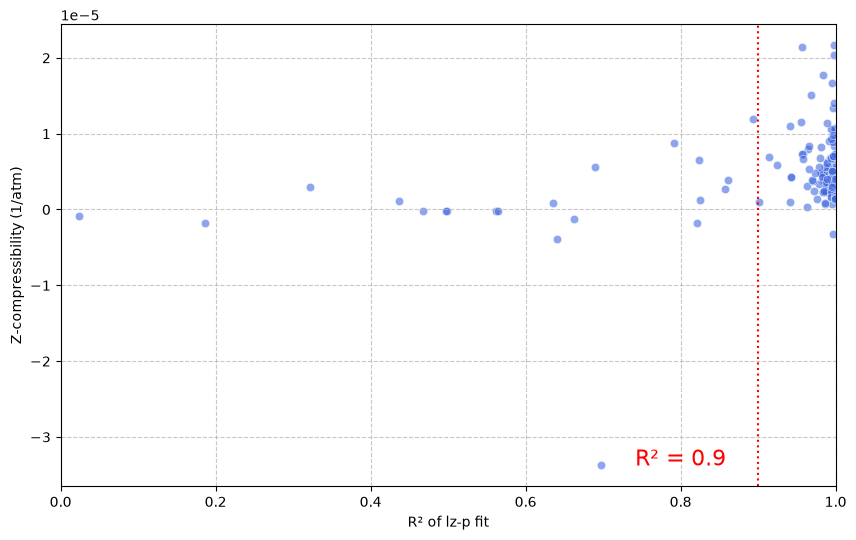

n=1: 113
n=2: 19
n=3: 19
n=4: 7
n=5: 3
n=6: 2
n=7: 2
✓ Boxplot (n=1 t/m 7) opgeslagen in: ./plots\compressibility_n1_to_n7_boxplot.png


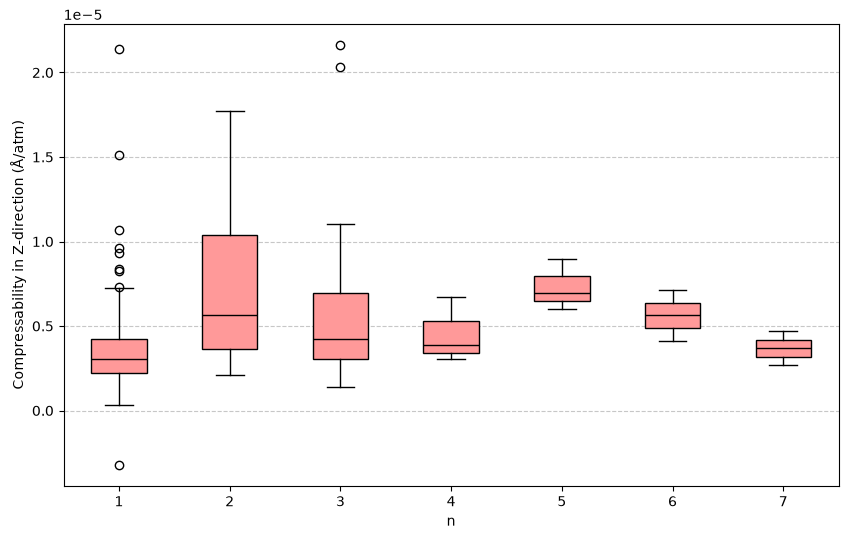

for RP: 52 datapoints
for DJ: 25 datapoints
for else: 102 datapoints
✓ Boxplot opgeslagen in: ./plots\compressibility_boxplot_mpl.png


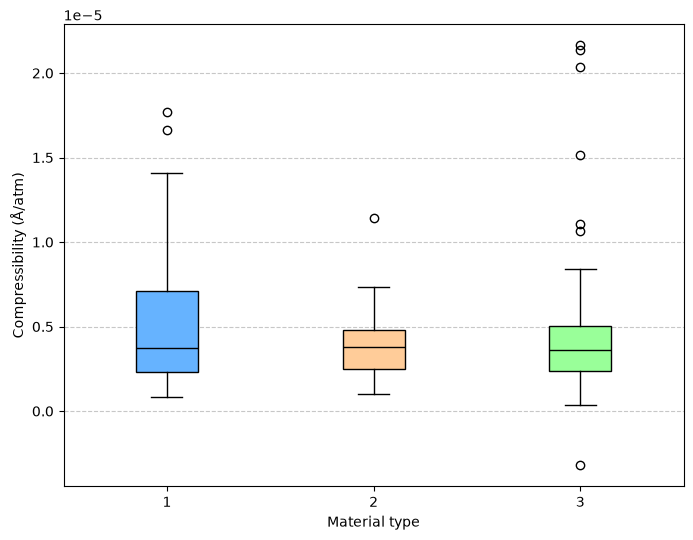

✓ Scatterplot (XY vs Z) opgeslagen in: ./plots\scatter_xy_vs_z_compressibility.png


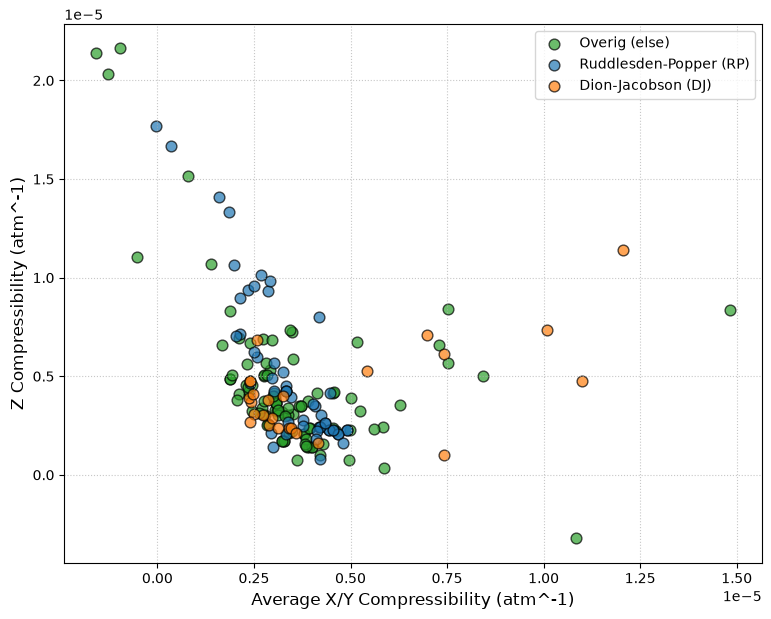

✓ Scatterplots opgeslagen in: ./plots\scatter_bandgaps_vs_z_compressibility.png


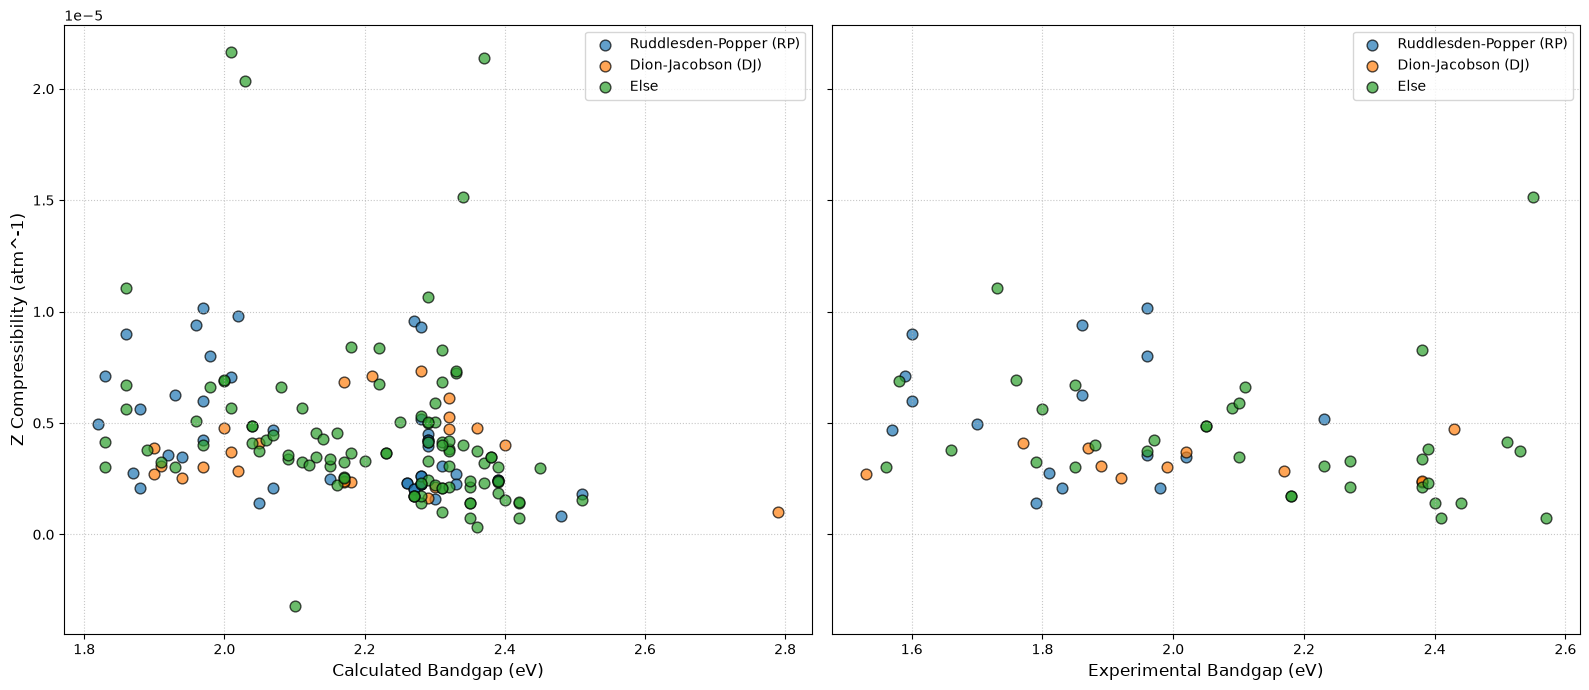

In [ ]:

plot_35_en_41(csv_path="combined_perovskite_data.csv")
plot_compressibility_per_n(csv_path="combined_perovskite_data.csv", output_dir="./plots")
plot_compressibility_per_type_matplotlib(csv_path="combined_perovskite_data.csv", output_dir="./plots")
plot_scatter_xy_vs_z_compressibility(csv_path="combined_perovskite_data.csv", output_dir="./plots")
plot_bandgaps_vs_z_compressibility(csv_path="combined_perovskite_data.csv", output_dir="./plots")
